# Exclusion Decision Validation (Step01 Baseline)

This notebook validates exclusion decisions using the **step01 cleaned baseline**:

- Input: `data/stepwise_cleaned_versions/01_participant_level_checks/participant_level_checks__step01_drop_items_and_flagged_participants/ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv`
- Goal: verify resulting sample quality and provide quick diagnostics before next modeling steps.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Load step01 baseline
PROJECT_ROOT = Path("..").resolve().parent
STEP01_PATH = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "01_participant_level_checks"
    / "participant_level_checks__step01_drop_items_and_flagged_participants"
    / "ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv"
)

raw = pd.read_csv(STEP01_PATH, header=None)
labels_row = raw.iloc[0].fillna("").astype(str).tolist()
codes_row = raw.iloc[1].fillna("").astype(str).tolist()
responses = raw.iloc[2:, :].reset_index(drop=True)

N_DEMOGRAPHICS = 5

# Robust item selection: keep only columns with ART-like item codes.
codes_series = pd.Series(codes_row)
item_code_mask = codes_series.str.contains(r"^(fill\s*\d+|mod\d+|cla\d+|soc\d+|det\d+|fan\d+|sci\d+)$", case=False, regex=True, na=False)
item_indices = [i for i in range(N_DEMOGRAPHICS, len(codes_row)) if item_code_mask.iloc[i]]

item_labels = [labels_row[i] for i in item_indices]
item_codes = [codes_row[i] for i in item_indices]

item_block = responses.iloc[:, item_indices].copy()
item_block.columns = pd.RangeIndex(item_block.shape[1])
item_numeric = item_block.replace({"falce": 0, "false": 0, "": np.nan}).apply(pd.to_numeric, errors="coerce")

participant_id = pd.Series(np.arange(1, len(item_numeric) + 1), name="participant_id")
code_s = pd.Series(item_codes)
is_foil = code_s.str.contains(r"^fill\s*\d+$", case=False, regex=True)
is_real = ~is_foil & code_s.str.strip().ne("")

print(f"Loaded: {STEP01_PATH}")
print(f"Participants: {len(item_numeric)}")
print(f"Analyzable items: {item_numeric.shape[1]} (real={int(is_real.sum())}, foil={int(is_foil.sum())})")

/tmp/ipykernel_129488/2204010764.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  item_code_mask = codes_series.str.contains(r"^(fill\s*\d+|mod\d+|cla\d+|soc\d+|det\d+|fan\d+|sci\d+)$", case=False, regex=True, na=False)
/tmp/ipykernel_129488/2204010764.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  item_numeric = item_block.replace({"falce": 0, "false": 0, "": np.nan}).apply(pd.to_numeric, errors="coerce")


Loaded: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/01_participant_level_checks/participant_level_checks__step01_drop_items_and_flagged_participants/ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv
Participants: 1010
Analyzable items: 207 (real=100, foil=107)


### Commentary: Data loading

- **1,010 participants** remain after removing 25 flagged respondents (original: 1,035). This is a modest 2.4% loss.
- **207 analyzable items** remain (100 real authors + 107 foils) after dropping 5 late-added items with structural missingness plus the duplicate Ian Fleming column already handled in data prep. The real-to-foil ratio stays close to 1:1.
- The two warnings are cosmetic (pandas regex grouping hint and a `replace` deprecation notice) — they do not affect results.

In [3]:
# Core validation summary after exclusions
n_items = item_numeric.shape[1]

n_missing = item_numeric.isna().sum(axis=1)
missing_pct = n_missing / n_items
ones = item_numeric.eq(1).sum(axis=1)
valid_n = item_numeric.notna().sum(axis=1)
ones_rate = ones / valid_n.replace(0, np.nan)

hits = item_numeric.loc[:, is_real.values].eq(1).sum(axis=1)
false_alarms = item_numeric.loc[:, is_foil.values].eq(1).sum(axis=1)

n_real_valid = item_numeric.loc[:, is_real.values].notna().sum(axis=1)
n_foil_valid = item_numeric.loc[:, is_foil.values].notna().sum(axis=1)

hit_rate = hits / n_real_valid.replace(0, np.nan)
fa_rate = false_alarms / n_foil_valid.replace(0, np.nan)
corrected = hit_rate - fa_rate

summary = pd.DataFrame({
    "participant_id": participant_id,
    "n_missing": n_missing,
    "missing_pct": missing_pct,
    "ones_rate": ones_rate,
    "hits": hits,
    "false_alarms": false_alarms,
    "hit_rate": hit_rate,
    "fa_rate": fa_rate,
    "corrected_score": corrected,
})

print("Participant-level quality summary (post-step01)")
print("\nMissingness")
print(summary["missing_pct"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())

print("\nFalse-alarm rate")
print(summary["fa_rate"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())

print("\nCorrected score")
print(summary["corrected_score"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

Participant-level quality summary (post-step01)

Missingness
count    1010.000000
mean        0.009667
std         0.000152
min         0.009662
50%         0.009662
90%         0.009662
95%         0.009662
99%         0.009662
max         0.014493

False-alarm rate
count    1010.000000
mean        0.038161
std         0.050047
min         0.000000
50%         0.019048
90%         0.104762
95%         0.138571
99%         0.246762
max         0.295238

Corrected score
count    1010.000000
mean        0.474629
std         0.205682
min        -0.005714
5%          0.150476
25%         0.312500
50%         0.471190
75%         0.640952
95%         0.801429
max         0.970000


### Commentary: Participant-level quality summary

**Missingness:**
- Now essentially zero for everyone: mean = 0.97%, max = 1.4% (just 2–3 items per person). The remaining missingness is from the single Ian Fleming cell that had 1 missing value — structurally harmless.

**False-alarm rate:**
- After excluding the 15 high-FA participants, the distribution is much cleaner: mean FA rate = 3.8%, median = 1.9%.
- The 99th percentile is now 0.247 — safely below the 0.30 threshold. The maximum remaining FA rate is 0.295, just under the cutoff.
- This confirms the exclusion criterion worked: no one in the cleaned sample endorses more than ~30% of foils.

**Corrected score:**
- Mean = 0.475 (nearly identical to the pre-exclusion mean of 0.473), confirming that the excluded participants were not driving the central tendency.
- The 5th percentile rose slightly to 0.150 (was 0.143), and the minimum is still near zero (−0.006). The distribution is healthy and approximately symmetric around the median (0.471).
- No negative corrected scores of practical concern — nobody endorses more foils than real authors.

In [4]:
# Validate that extreme response-style cases are now absent
near_all_0_max = 0.05
near_all_1_min = 0.95
fa_high_threshold = 0.30

flags = pd.DataFrame({
    "near_all_0": summary["ones_rate"].gt(0) & summary["ones_rate"].le(near_all_0_max),
    "all_0": summary["ones_rate"].eq(0),
    "near_all_1": summary["ones_rate"].lt(1) & summary["ones_rate"].ge(near_all_1_min),
    "all_1": summary["ones_rate"].eq(1),
    "high_fa": summary["fa_rate"].ge(fa_high_threshold),
})

flag_counts = flags.sum().rename("count").to_frame()
flag_counts["proportion"] = flag_counts["count"] / len(summary)

print("Residual extreme-pattern checks after step01")
display(flag_counts)

remaining_flagged = summary.loc[flags.any(axis=1)].copy()
print("Participants still flagged by any criterion:", len(remaining_flagged))
if len(remaining_flagged) > 0:
    display(remaining_flagged.sort_values(["fa_rate", "ones_rate"], ascending=[False, True]).head(30))

Residual extreme-pattern checks after step01


,count,proportion
near_all_0,0,0.0
all_0,0,0.0
near_all_1,0,0.0
all_1,0,0.0
high_fa,0,0.0


Participants still flagged by any criterion: 0


### Commentary: Residual extreme-pattern checks

This is the key validation table. All five flag categories show **exactly 0** remaining cases:

| Flag | Count | Meaning |
|---|---|---|
| `near_all_0` | 0 | No one endorsing <=5% of items |
| `all_0` | 0 | No one endorsing zero items |
| `near_all_1` | 0 | No one endorsing >=95% of items |
| `all_1` | 0 | No one endorsing everything |
| `high_fa` | 0 | No one with FA rate >= 30% |

**Conclusion:** The step01 exclusion successfully removed all participants with extreme response-style problems. The cleaned sample contains no residual cases that would distort item calibration.

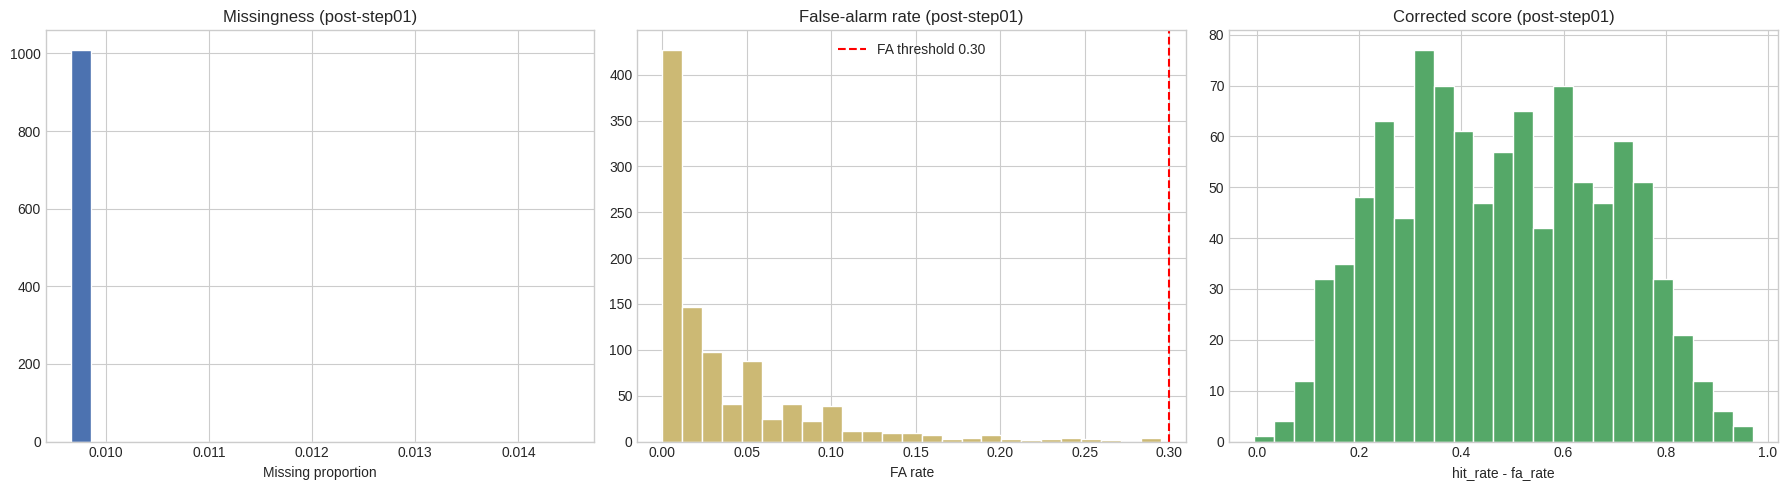

In [5]:
# Quick visuals for decision validation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(summary["missing_pct"].dropna(), bins=25, color="#4C72B0", edgecolor="white")
axes[0].set_title("Missingness (post-step01)")
axes[0].set_xlabel("Missing proportion")

axes[1].hist(summary["fa_rate"].dropna(), bins=25, color="#CCB974", edgecolor="white")
axes[1].axvline(0.30, color="red", linestyle="--", linewidth=1.5, label="FA threshold 0.30")
axes[1].set_title("False-alarm rate (post-step01)")
axes[1].set_xlabel("FA rate")
axes[1].legend()

axes[2].hist(summary["corrected_score"].dropna(), bins=25, color="#55A868", edgecolor="white")
axes[2].set_title("Corrected score (post-step01)")
axes[2].set_xlabel("hit_rate - fa_rate")

plt.tight_layout()
plt.show()

### Commentary: Validation plots

**Missingness (left panel):**
- A single narrow bar near zero — virtually no missingness left. This is exactly what we expect after removing structurally missing items.

**False-alarm rate (middle panel):**
- Strongly right-skewed with the bulk of participants near zero FA. The red dashed line at 0.30 shows the exclusion threshold — all remaining participants fall to its left. The tail tapers off well before the cutoff.

**Corrected score (right panel):**
- Approximately bell-shaped, centered around 0.47. Healthy spread (SD ~ 0.21) reflecting genuine individual differences in author recognition. No suspicious spikes at the extremes (no floor or ceiling effects).

**Overall verdict:** The distributions look clean and well-behaved. The step01 exclusions were effective without being overly aggressive — sample size remains large (N=1,010) and the score distributions show no artifacts.

### Interpretation Template

Use this notebook to decide whether step01 exclusion was too strict, too lenient, or appropriate:

- If residual `high_fa`/`near_all_0` cases remain, consider a second exclusion pass.
- If distributions look stable and residual flags are near zero, keep step01 as final participant-level cleaning.
- If sample loss is too high for planned analyses, test alternative FA thresholds (e.g., 0.35) and compare impacts.

In [ ]:
# Export publication-ready validation package (main text + appendix)
from pathlib import Path

export_dir = PROJECT_ROOT / "results" / "exclusion_decision_validation_article_package_2026-04-06"
export_dir.mkdir(parents=True, exist_ok=True)

# Residual-flag thresholds (same as validation section)
near_all_0_max = 0.05
near_all_1_min = 0.95
fa_high_threshold = 0.30

flags = pd.DataFrame(
    {
        "near_all_0": summary["ones_rate"].gt(0) & summary["ones_rate"].le(near_all_0_max),
        "all_0": summary["ones_rate"].eq(0),
        "near_all_1": summary["ones_rate"].lt(1) & summary["ones_rate"].ge(near_all_1_min),
        "all_1": summary["ones_rate"].eq(1),
        "high_fa": summary["fa_rate"].ge(fa_high_threshold),
    }
)

flag_counts = flags.sum().rename("count").to_frame()
flag_counts["proportion"] = flag_counts["count"] / len(summary)
flag_counts = flag_counts.reset_index().rename(columns={"index": "flag"})

remaining_flagged = summary.loc[flags.any(axis=1)].copy()

overview_summary = pd.DataFrame(
    {
        "metric": [
            "n_participants_post_step01",
            "n_analyzable_items",
            "n_real_items",
            "n_foil_items",
            "mean_missing_pct",
            "max_missing_pct",
            "mean_fa_rate",
            "max_fa_rate",
            "mean_corrected_score",
            "median_corrected_score",
            "n_residual_flagged_any_criterion",
        ],
        "value": [
            len(summary),
            item_numeric.shape[1],
            int(is_real.sum()),
            int(is_foil.sum()),
            float(summary["missing_pct"].mean()),
            float(summary["missing_pct"].max()),
            float(summary["fa_rate"].mean()),
            float(summary["fa_rate"].max()),
            float(summary["corrected_score"].mean()),
            float(summary["corrected_score"].median()),
            int(len(remaining_flagged)),
        ],
    }
)

distribution_descriptives = pd.concat(
    [
        summary["missing_pct"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame().T,
        summary["fa_rate"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame().T,
        summary["corrected_score"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame().T,
    ],
    axis=0,
)
distribution_descriptives.index = ["missing_pct", "fa_rate", "corrected_score"]

# Table exports (CSV only)
summary.to_csv(export_dir / "table_post_step01_participant_summary_full.csv", index=False)
distribution_descriptives.to_csv(export_dir / "table_post_step01_distribution_descriptives.csv")
flag_counts.to_csv(export_dir / "table_post_step01_residual_flag_counts.csv", index=False)
remaining_flagged.to_csv(export_dir / "table_post_step01_residual_flagged_participants.csv", index=False)
overview_summary.to_csv(export_dir / "table_post_step01_overview_key_metrics.csv", index=False)
summary.sort_values(["fa_rate", "participant_id"], ascending=[False, True]).head(20).to_csv(
    export_dir / "table_post_step01_top20_by_false_alarm_rate.csv", index=False
)

# Plot exports (PNG + PDF)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(summary["missing_pct"].dropna(), bins=25, color="#4C72B0", edgecolor="white")
axes[0].set_title("Missingness (post-step01)")
axes[0].set_xlabel("Missing proportion")

axes[1].hist(summary["fa_rate"].dropna(), bins=25, color="#CCB974", edgecolor="white")
axes[1].axvline(0.30, color="red", linestyle="--", linewidth=1.5, label="FA threshold 0.30")
axes[1].set_title("False-alarm rate (post-step01)")
axes[1].set_xlabel("FA rate")
axes[1].legend()

axes[2].hist(summary["corrected_score"].dropna(), bins=25, color="#55A868", edgecolor="white")
axes[2].set_title("Corrected score (post-step01)")
axes[2].set_xlabel("hit_rate - fa_rate")

plt.tight_layout()
fig.savefig(export_dir / "figure_post_step01_validation_histograms_missingness_fa_corrected.png", dpi=300, bbox_inches="tight")
fig.savefig(export_dir / "figure_post_step01_validation_histograms_missingness_fa_corrected.pdf", bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(flag_counts["flag"], flag_counts["count"], color="#4C72B0")
ax.set_title("Residual extreme-pattern flags after step01")
ax.set_xlabel("Flag")
ax.set_ylabel("Count")
for i, row in flag_counts.iterrows():
    ax.text(i, row["count"] + 0.02, f"{int(row['count'])}", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, max(1, flag_counts["count"].max()) + 0.4)
plt.tight_layout()
fig.savefig(export_dir / "figure_post_step01_residual_flag_counts.png", dpi=300, bbox_inches="tight")
fig.savefig(export_dir / "figure_post_step01_residual_flag_counts.pdf", bbox_inches="tight")
plt.close(fig)

# Package index/manifest
readme_text = """# Exclusion Decision Validation Article Package

This folder contains publication-oriented exports derived from `scripts/eda/02_exclusion_decision_validation.ipynb`.

## Suggested Main Text Artifacts

- `figure_post_step01_validation_histograms_missingness_fa_corrected.png` / `.pdf`: Core post-cleaning distribution panel for missingness, false-alarm rate, and corrected score.
- `figure_post_step01_residual_flag_counts.png` / `.pdf`: Key validation figure showing residual extreme-pattern flag counts.
- `table_post_step01_overview_key_metrics.csv`: Compact metrics table for reporting post-step01 sample quality.
- `table_post_step01_distribution_descriptives.csv`: Descriptive statistics for missingness, FA rate, and corrected score.

## Suggested Appendix / Reproducibility Artifacts

- `table_post_step01_participant_summary_full.csv`: Full participant-level post-step01 validation table.
- `table_post_step01_residual_flag_counts.csv`: Underlying counts/proportions for each residual flag criterion.
- `table_post_step01_residual_flagged_participants.csv`: Participant rows still flagged by any criterion (empty if no residual flags).
- `table_post_step01_top20_by_false_alarm_rate.csv`: Highest post-step01 FA rates for transparent threshold proximity checks.

## Notes

- Source data: `ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv`.
- Item selection keeps only ART-like item-code columns matching:
  `fill`, `mod`, `cla`, `soc`, `det`, `fan`, `sci` prefixes.
- Residual-flag thresholds mirror notebook logic:
  - `near_all_0`: `ones_rate > 0` and `<= 0.05`
  - `near_all_1`: `ones_rate < 1` and `>= 0.95`
  - `high_fa`: `fa_rate >= 0.30`
"""
(export_dir / "README.md").write_text(readme_text, encoding="utf-8")

print(f"Saved validation package to: {export_dir}")
print("Done: CSV tables, PNG+PDF figures, and README manifest.")